# Attention Mechanism


Different types of attention: 
```
Attention
│
├── Additive Attention
├── Dot Product Attention
│
└── Transformer Attention
      │
      ├── Self Attention
      ├── Cross Attention
      ├── Multi Head Attention
      ├── Causal Attention
      ├── Bidirectional Attention
      │
      ├── Sparse Attention
      ├── Local Attention
      ├── Global Attention
      ├── Linear Attention
      │
      ├── MQA
      ├── GQA
      └── Flash Attention
```

In [1]:
import numpy as np
import math, os, re 

In [2]:
L, d_k, d_v = 4, 8, 8

Q = np.random.randn(L, d_k)
K = np.random.randn(L, d_k)
V = np.random.randn(L, d_v)

Q, K, V

(array([[-1.26885357,  0.26530582, -1.37482425, -0.56269915,  1.542848  ,
         -0.66872026, -0.43659747,  0.14725229],
        [ 0.05151963,  1.08344368, -0.19811766,  1.26613015, -1.17974531,
         -0.37889271,  1.31299215, -0.15562054],
        [ 0.86045551,  0.6519253 , -1.63336731, -2.23093829, -2.00478595,
          0.20601058,  0.17291874, -0.31102805],
        [-0.06741109, -0.81499709, -1.7029138 , -0.14467865,  1.56369374,
          0.51802883,  1.19744937, -0.70540382]]),
 array([[-0.3913303 , -0.96949019,  1.60691439, -1.41131489, -0.10947126,
          1.11847743, -0.4807852 ,  1.00752982],
        [ 1.19148665,  0.81797924, -0.06333619,  1.40297286, -0.84414878,
          1.26341379,  0.47992693,  0.02489031],
        [ 0.7215404 , -0.53439894, -1.05623741, -0.3731825 , -0.65270041,
         -0.61437573, -0.2296444 , -0.40078363],
        [ 2.10867373, -0.84397785, -0.62886276,  1.65737718, -0.10525044,
         -0.83025456, -1.22892358,  0.0888668 ]]),
 array([[-1.

## Scaled Dot Product Attention

$self attention = softmax \left({\dfrac{Q\cdot K^{T}}{\sqrt{d_k}}}+M\right)V$

In [3]:
scaled = np.matmul(Q, K.T) / math.sqrt(d_k)
scaled

array([[-0.61317652, -1.53806909,  0.01764085, -0.71597602],
       [-1.50561062,  1.371774  , -0.01463866,  0.08083265],
       [-0.13841781,  0.19793651,  1.44855698, -0.5679176 ],
       [-0.9170981 , -0.33604161,  0.32116982, -0.26591901]])

In [4]:
# Masking is required in the decoder to ensure that we 
# don't get context from words generated in the future

mask = np.tril(np.ones((L, L)))
mask

array([[1., 0., 0., 0.],
       [1., 1., 0., 0.],
       [1., 1., 1., 0.],
       [1., 1., 1., 1.]])

In [5]:
# transform the matrix such that 1 -> 0 and 0 -> -inf
# because the softmax is better if the values are in that range
mask[mask == 0] = -np.inf
mask[mask == 1] = 0
mask

array([[  0., -inf, -inf, -inf],
       [  0.,   0., -inf, -inf],
       [  0.,   0.,   0., -inf],
       [  0.,   0.,   0.,   0.]])

In [6]:
def softmax(x):
    return (np.exp(x).T / np.sum(np.exp(x), axis=-1)).T

In [7]:
self_attention = softmax(scaled + mask)

In [8]:
self_attention

array([[1.        , 0.        , 0.        , 0.        ],
       [0.05328291, 0.94671709, 0.        , 0.        ],
       [0.13719733, 0.19205362, 0.67074905, 0.        ],
       [0.12261874, 0.21923328, 0.42298968, 0.23515831]])

In [9]:
new_V = np.matmul(self_attention, V)
new_V

array([[-1.05930556, -2.30181019, -0.18232486, -2.13290877,  0.68976583,
        -1.94229919,  0.23177614, -1.88583797],
       [ 0.41235719, -0.16714569,  1.2316896 , -2.09914829,  0.31896895,
         1.24829807, -0.7625154 ,  0.3839333 ],
       [-0.06478074, -0.92793448, -0.23949169, -0.4685663 , -0.72447404,
         0.57596835, -0.41987503, -1.07822103],
       [-0.39844449, -0.67595574,  0.0870629 , -0.76771713, -0.1970464 ,
         0.38522851, -0.20876693, -0.44239883]])

In [10]:
V

array([[-1.05930556, -2.30181019, -0.18232486, -2.13290877,  0.68976583,
        -1.94229919,  0.23177614, -1.88583797],
       [ 0.49518497, -0.047003  ,  1.31127284, -2.09724819,  0.29809985,
         1.42787053, -0.81847589,  0.51168004],
       [-0.02169054, -0.89915172, -0.69521068,  0.33819981, -1.30653816,
         0.84714084, -0.43903579, -1.36826   ],
       [-1.56464781, -0.01307272,  0.49333426, -0.80563168,  0.87461987,
        -0.20402331,  0.54413444,  1.08617382]])

In [11]:
def scaled_attention(Q, K, V, mask=None):
    dk = Q.shape[-1]
    scaled = np.matmul(Q, K.T) / math.sqrt(d_k)
    if mask is not None:
        scaled = scaled + mask 
    attention = softmax(scaled)
    out = np.matmul(attention, V)
    return out, attention 

mask = np.tril(np.ones((L, L)))

values, attention = scaled_attention(Q, K, V, mask)

In [12]:
values, attention

(array([[-0.70139927, -1.35288721, -0.14192887, -1.13985913,  0.05549185,
         -0.56063047, -0.00484861, -1.10482955],
        [ 0.22032243, -0.2085466 ,  1.0300779 , -1.8150125 ,  0.24432254,
          1.10117039, -0.63290069,  0.31183265],
        [-0.11248287, -0.898838  , -0.21618472, -0.47928641, -0.67361608,
          0.55116131, -0.38921544, -1.0093841 ],
        [-0.39844449, -0.67595574,  0.0870629 , -0.76771713, -0.1970464 ,
          0.38522851, -0.20876693, -0.44239883]]),
 array([[0.46101409, 0.067258  , 0.31869865, 0.15302925],
        [0.04504661, 0.80037654, 0.07360181, 0.08097504],
        [0.13283388, 0.1859455 , 0.64941639, 0.03180424],
        [0.12261874, 0.21923328, 0.42298968, 0.23515831]]))

## Multi Headed Attention

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [14]:
sequence_length = 4
batch_size = 1
input_dim = 512
d_model = 512
x = torch.randn((batch_size, sequence_length, input_dim))

In [15]:
x.size() # randomly sampled input going directly into the mha phase

torch.Size([1, 4, 512])

In [16]:
# mapping the input from 512 to 3 * model_dimension
qkv_layer = nn.Linear(input_dim, 3 * d_model)

In [17]:
qkv = qkv_layer(x)

In [18]:
qkv.shape

torch.Size([1, 4, 1536])

Text(0.5, 1.0, 'qkv distribution')

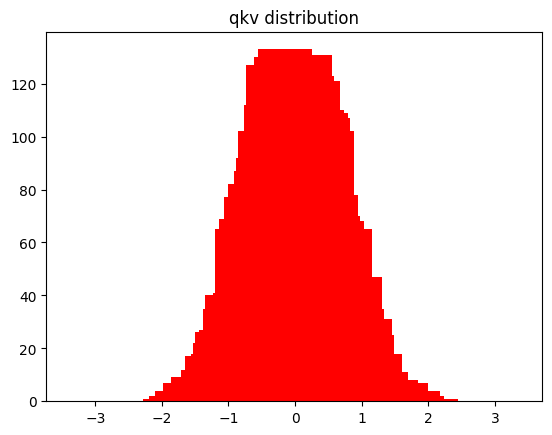

In [19]:
y_val = torch.histc(qkv, bins=200, min=-3, max=3)
x_val = np.arange(-1, 1, 0.01) * 3
plt.bar(x_val, y_val, align='center', color='red')
plt.title('qkv distribution')

In [20]:
num_heads = 8
head_dim = d_model // num_heads 
qkv = qkv.reshape(batch_size, sequence_length, num_heads, 3 * head_dim)

In [21]:
qkv.shape

torch.Size([1, 4, 8, 192])

In [22]:
# switching the second and third dimensions so that the 
# head and number of seqeunces are swapped making it 
# easier to perform parallel operations on the last two dimensions
qkv = qkv.permute(0, 2, 1, 3) 
qkv.shape

torch.Size([1, 8, 4, 192])

In [23]:
# breaking down the qkv tensor along the last dimension
q, k, v = qkv.chunk(3, dim=-1)
q.shape, k.shape, v.shape

(torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]))

In [24]:
d_k = q.size()[-1]
scaled = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
scaled.shape

torch.Size([1, 8, 4, 4])

In [25]:
k.T.shape

C:\Users\108pa\AppData\Local\Temp\ipykernel_33732\3717780648.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4484.)
  k.T.shape


torch.Size([64, 4, 8, 1])

In [26]:
mask = torch.full(scaled.size(), float('-inf')) # we're taking -inf because we're using a softmax function
mask = torch.triu(mask, diagonal=1) # upper triangular mask (lower diagonal is filled with zeros)
mask[0][1]

tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])

In [27]:
(scaled + mask)[0][0]

tensor([[ 0.1440,    -inf,    -inf,    -inf],
        [-0.1070,  0.0333,    -inf,    -inf],
        [-0.1979, -0.0910,  0.2559,    -inf],
        [-0.4034, -0.1719,  0.5742,  0.0074]], grad_fn=<SelectBackward0>)

In [28]:
scaled += mask

In [29]:
attention = F.softmax(scaled, dim=-1)
attention.shape

torch.Size([1, 8, 4, 4])

In [30]:
attention[0][0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4650, 0.5350, 0.0000, 0.0000],
        [0.2712, 0.3018, 0.4270, 0.0000],
        [0.1556, 0.1961, 0.4136, 0.2346]], grad_fn=<SelectBackward0>)

In [31]:
# generating new value vectors according to the formula
values = torch.matmul(attention, v)
values.shape


torch.Size([1, 8, 4, 64])

In [32]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)
    if (mask is not None):
        scaled += mask 
    attention = F.softmax(scaled, dim=-1)
    values = torch.matmul(attention, v)
    return values, attention

In [33]:
values, attention = scaled_dot_product(q, k, v, mask=mask)

In [34]:
attention[0][0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4650, 0.5350, 0.0000, 0.0000],
        [0.2712, 0.3018, 0.4270, 0.0000],
        [0.1556, 0.1961, 0.4136, 0.2346]], grad_fn=<SelectBackward0>)

In [35]:
values.size()

torch.Size([1, 8, 4, 64])

In [36]:
values = values.reshape(batch_size, sequence_length, num_heads * head_dim)
values.size()

torch.Size([1, 4, 512])

In [37]:
linear_layer = nn.Linear(d_model, d_model)

In [38]:
out = linear_layer(values)

In [39]:
out.shape

torch.Size([1, 4, 512])

In [42]:
### putting everything we did into a class

class MultiheadAttention(nn.Module):

    def __init__(self, input_dim, d_model, num_heads):
        super().__init__()
        self.input_dim = input_dim 
        self.d_model = d_model 
        self.num_heads = num_heads 
        self.head_dim = d_model // num_heads 
        self.qkv_layer = nn.Linear(input_dim, 3 * d_model)
        self.linear_layer = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size, sequence_length, input_dim = x.size()
        print(f"x.size(): {x.size()}")
        qkv = self.qkv_layer(x)
        print(f"qkv.size() after qkv_layer: {qkv.size()}")
        qkv = qkv.reshape(batch_size, sequence_length, self.num_heads, 3 * self.head_dim)
        print(f"qkv.size() after reshape: {qkv.size()}")
        qkv = qkv.permute(0, 2, 1, 3)
        print(f"qkv.size() after permute: {qkv.size()}")
        q, k , v = qkv.chunk(3, dim=-1)
        values, attention = scaled_dot_product(q, k, v, mask)
        print(f"values.size() after scaled_dot_product: {values.size()}")
        values = values.reshape(batch_size, sequence_length, self.num_heads * self.head_dim)
        print(f"values.size() after reshape: {values.size()}")
        out = self.linear_layer(values)
        
        return out

In [43]:
input_dim = 1024
d_model = 512
num_heads = 8
batch_size = 30
sequence_length = 5
x = torch.randn((batch_size, sequence_length, input_dim))

model = MultiheadAttention(input_dim, d_model, num_heads)
out = model.forward(x)

x.size(): torch.Size([30, 5, 1024])
qkv.size() after qkv_layer: torch.Size([30, 5, 1536])
qkv.size() after reshape: torch.Size([30, 5, 8, 192])
qkv.size() after permute: torch.Size([30, 8, 5, 192])
values.size() after scaled_dot_product: torch.Size([30, 8, 5, 64])
values.size() after reshape: torch.Size([30, 5, 512])
